# Phase V — Model Selection and Validation
## Bank Marketing Dataset — ML Lab Project 2026

**Author:** Arman Bazarchi

---

**Prerequisites:** Run `preprocessing.ipynb` first to generate the processed data in `data/`.

In this notebook we evaluate and select the final model. We compare the best representative of each model
family from Phases II–IV plus the mandatory baseline, using **nested cross-validation** (the inner
loop tunes hyperparameters, the outer loop gives an *unbiased* generalization estimate), score them
on the classification metrics that matter under imbalance, run a **corrected paired t-test** (Nadeau &
Bengio) on the top models, then retrain the winner on the full training set and confirm it on the
held-out test set.

### Outline
1. Load Data
2. Candidate Models & the Nested-CV Scheme
3. Nested-CV Results (Accuracy, F1, ROC-AUC, AUPR)
4. Statistical Test (corrected paired t-test)
5. Final Model — Refit on Full Train, Confirm on Test
6. Summary & Discussion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve, precision_recall_curve, classification_report)
from scipy.stats import ttest_rel

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Load Data

Same feature sets and 80/20 split as Phases II–IV. We run the nested CV on the **full 33k training
set** (no subsample). Nested CV multiplies the number of fits and the kernel SVM is O(n²–n³), but the
whole comparison still finishes in a few minutes (the RBF SVM is the only slow part, ~4 min; the other
models take seconds). This keeps every model compared on *identical data and folds* (a fair, paired
comparison) at full size.

**Note on metrics:** our task is binary **classification**, so we focus on Accuracy, F1, ROC-AUC and
AUPR. The regression metrics in the brief (R², MAE, RMSE) do not apply here (in Phase II Ridge/Lasso
was a separate Linear-Probability-Model aside, not our prediction task).

In [2]:
X_scaled_df = pd.read_csv('data/X_scaled.csv')
cat_features = pd.read_csv('data/cat_features.csv')
y = pd.read_csv('data/y.csv')['y']

X_num = X_scaled_df.drop(columns=['duration'])                  # drop leaky duration
X_cat = pd.get_dummies(cat_features, drop_first=True).astype(int)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Nested CV runs on the FULL training set (no subsample); the final model is also fit on all of it.
print(f"Train: {X_train.shape[0]}   Test: {X_test.shape[0]}")
print(f"Positive rate -- train {y_train.mean()*100:.2f}% / test {y_test.mean()*100:.2f}%")

Train: 32950   Test: 8238
Positive rate -- train 11.27% / test 11.26%


---
## 2. Candidate Models & the Nested-CV Scheme

We compare the best representative of each family against the mandatory baseline:
- **Baseline** — stratified chance (must be beaten).
- **Logistic Regression** (Phase II) — linear.
- **SVM (RBF)** (Phase III) — kernel.
- **Random Forest** (Phase IV) — bagging.
- **Hist Gradient Boosting** (Phase IV) — boosting (the histogram booster supports
  `class_weight`, so imbalance is handled cleanly inside CV).

**Nested CV:** for each model an inner 3-fold `GridSearchCV` (scored on ROC-AUC) tunes the
hyperparameters, wrapped in an outer 5-fold loop that scores the tuned model on held-out folds.
Because tuning happens *inside* each outer fold, the outer scores are an **unbiased** estimate of
generalization, unlike tuning and reporting on the same data. All models share the same outer/inner
folds, so the comparison (and the later paired t-test) is properly paired.

In [3]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc', 'aupr': 'average_precision'}

candidates = {
    'Logistic Regression':    (LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
                               {'C': [0.1, 1, 10]}),
    'SVM (RBF)':              (SVC(kernel='rbf', class_weight='balanced', random_state=42),
                               {'C': [1, 10], 'gamma': ['scale', 0.01]}),
    'Random Forest':          (RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=42),
                               {'n_estimators': [300], 'min_samples_leaf': [1, 5]}),
    'Hist Gradient Boosting': (HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
                               {'learning_rate': [0.05, 0.1], 'max_leaf_nodes': [15, 31]}),
}

# Nested CV on the FULL training set (the SVM dominates the runtime, ~4 min, the rest are fast)
results = {}   # model and cross_validate output (per-fold scores for every metric)
for name, (est, grid) in candidates.items():
    gs = GridSearchCV(est, grid, scoring='roc_auc', cv=inner_cv, n_jobs=1)
    results[name] = cross_validate(gs, X_train, y_train, cv=outer_cv, scoring=scoring, n_jobs=-1)
    print(f"{name:>24s}: nested ROC-AUC = {results[name]['test_roc_auc'].mean():.4f} "
          f"+/- {results[name]['test_roc_auc'].std():.4f}")

# Baseline (no tuning needed)
dummy = DummyClassifier(strategy='stratified', random_state=42)
results['Baseline (dummy)'] = cross_validate(dummy, X_train, y_train, cv=outer_cv, scoring=scoring, n_jobs=-1)
print(f"{'Baseline (dummy)':>24s}: nested ROC-AUC = {results['Baseline (dummy)']['test_roc_auc'].mean():.4f}")

# Here we apply the nested-CV, then chek and interpret the results in next cell.



     Logistic Regression: nested ROC-AUC = 0.7848 +/- 0.0057


               SVM (RBF): nested ROC-AUC = 0.7749 +/- 0.0021


           Random Forest: nested ROC-AUC = 0.7916 +/- 0.0033


  Hist Gradient Boosting: nested ROC-AUC = 0.7980 +/- 0.0032


        Baseline (dummy): nested ROC-AUC = 0.5055


---
## 3. Nested-CV Results (Accuracy, F1, ROC-AUC, AUPR)

In [4]:
metrics = ['accuracy', 'f1', 'roc_auc', 'aupr']
summary = pd.DataFrame(
    {name: {m: results[name][f'test_{m}'].mean() for m in metrics} for name in results}).T
summary_std = pd.DataFrame(
    {name: {m: results[name][f'test_{m}'].std() for m in metrics} for name in results}).T

# Display "mean ± std" table, sorted by ROC-AUC
disp = summary.copy()
for m in metrics:
    disp[m] = [f"{summary.loc[i, m]:.3f} ± {summary_std.loc[i, m]:.3f}" for i in summary.index]
disp = disp.loc[summary.sort_values('roc_auc', ascending=False).index]
print("Nested-CV performance (mean ± std over 5 outer folds):")
print(disp.to_string())

# On the full data the models are more clearly seperated (a smaller subsample would blur them into a tie):
# the two ENSEMBLES lead -- Hist Gradient Boosting (ROC-AUC 0.798, AUPR 0.466) and Random Forest
# (0.792, 0.466) -- comfortably above Logistic Regression (0.785 / 0.415) and the RBF SVM
# (0.775 / 0.398), the baseline sits at chance. Random Forest also has the best F1 (0.494) and
# accuracy (0.865) with bigger difference from others. 

# Fold-to-fold std is small (~0.003-0.013), so these gaps seem stable.
# These nested-CV numbers are slightly below the single held-out test scores (e.g. RF test ROC-AUC
# 0.807 in Phase IV): because each outer fold trains on only 4/5 of the data and we average over
# 5 folds rather than scoring one (favourable) split. 
# Nested CV provides a slightly less biased comparison of model performance.


Nested-CV performance (mean ± std over 5 outer folds):
                             accuracy             f1        roc_auc           aupr
Hist Gradient Boosting  0.838 ± 0.005  0.467 ± 0.006  0.798 ± 0.003  0.466 ± 0.013
Random Forest           0.865 ± 0.002  0.494 ± 0.006  0.792 ± 0.003  0.466 ± 0.010
Logistic Regression     0.823 ± 0.003  0.442 ± 0.005  0.785 ± 0.006  0.415 ± 0.003
SVM (RBF)               0.836 ± 0.006  0.457 ± 0.009  0.775 ± 0.002  0.398 ± 0.005
Baseline (dummy)        0.804 ± 0.002  0.122 ± 0.009  0.506 ± 0.005  0.114 ± 0.001


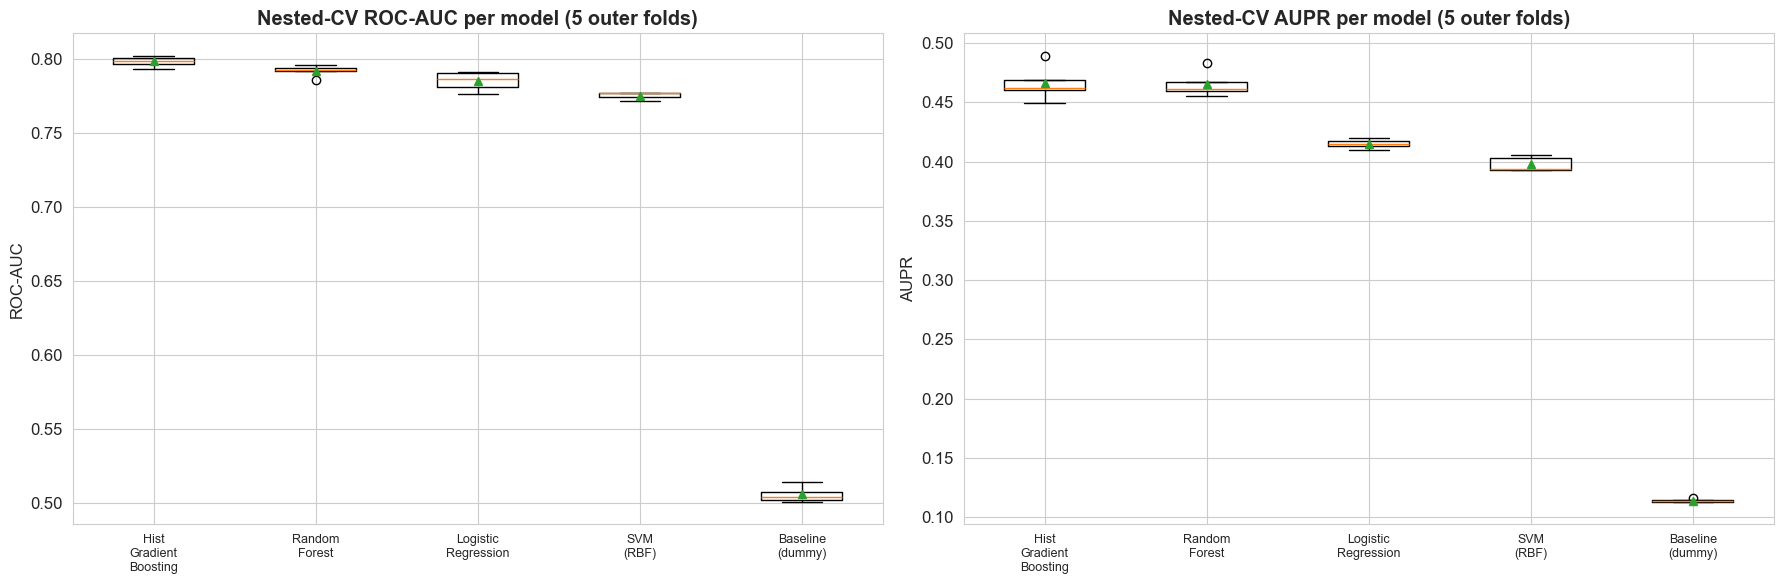

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
order = summary.sort_values('roc_auc', ascending=False).index
for ax, metric, title in zip(axes, ['roc_auc', 'aupr'], ['ROC-AUC', 'AUPR']):
    data = [results[name][f'test_{metric}'] for name in order]
    ax.boxplot(data, labels=[o.replace(' ', '\n') for o in order], showmeans=True)
    ax.set_title(f'Nested-CV {title} per model (5 outer folds)', fontweight='bold')
    ax.set_ylabel(title); ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()

# The boxplots show the spread across the 5 outer folds, not just the mean, and the boxes seem tight
# (std ~0.003-0.013), so the ranking is stable, not fold-luck.

# ROC-AUC (left): the two ensemble boxes sit clearly highest with little overlap with Logistic/SVM;
#   HistGB edges Random Forest, and the baseline sits far below near 0.5.
#   
# AUPR (right): the Random Forest and HistGB boxes overlap almost entirely (the statistical tie),
#   both well above Logistic and SVM, their AUPR boxes are a little wider than their ROC-AUC boxes,
#   because AUPR is noisier under heavy imbalance.

# Overall the picture is consistent across folds: ensembles > linear/kernel > baseline.

---
## 4. Statistical Test — Corrected Paired t-test & Model Choice

CV fold scores are **not independent** — in 5-fold CV any two outer training sets overlap by ~⅘ —
which makes a *naive* paired t-test underestimate the variance and report over-optimistic p-values.
We therefore use the **Nadeau & Bengio corrected resampled t-test**, which inflates the variance by
the train/test-overlap term (ρ = n_test/n_train = 1/(k−1) for k-fold). We print the naive value too,
so the effect of the correction is visible. We use it to ask:
1. On **ROC-AUC**, is the leader really above the runner-up?
2. On **AUPR** (the imbalance-appropriate metric), are the two leaders actually different?

We select on **AUPR** because it is threshold-free (robust), focused on the rare positive class (matches the goal), unaffected by the dominant negatives (imbalance-appropriate), and is the metric that best separates our candidates. If the AUPR leaders are statistically **tied**, we
break the tie by **F1** (and prefer the simpler / more interpretable model).

In [13]:
from scipy.stats import t as t_dist
cands = summary.drop(index='Baseline (dummy)')

# Nadeau & Bengio corrected resampled paired t-test. CV fold scores are NOT independent, the outer
# training sets overlap by ~4/5, so a naive paired t-test underestimates the variance and would show
# over-optimistic p-values. 
k = outer_cv.get_n_splits()

def corrected_t(a, b, k):
    d = np.asarray(a) - np.asarray(b)
    J = len(d)
    rho = 1.0 / (k - 1)                                   # test/train ratio for k-fold
    se = np.sqrt((1.0 / J + rho) * d.var(ddof=1))         # correct standard error
    tstat = d.mean() / se if se > 0 else 0.0
    return tstat, 2 * t_dist.sf(abs(tstat), df=J - 1)

def compare(label, m1, m2, metric):
    a, b = results[m1][f'test_{metric}'], results[m2][f'test_{metric}']
    tn, pn = ttest_rel(a, b)                              # naive (shown for reference)
    tc, pc = corrected_t(a, b, k)                         # Nadeau-Bengio corrected (what we use)
    print(f"{label}: {m1} ({a.mean():.4f}) vs {m2} ({b.mean():.4f})  diff={a.mean()-b.mean():+.4f}")
    print(f"      naive paired t : t={tn:.2f}, p={pn:.3f}")
    print(f"      corrected (NB) : t={tc:.2f}, p={pc:.3f}  -> {'significant' if pc < 0.05 else 'NOT significant'}")
    return pc

# (1) ROC-AUC leaders
roc_rank = cands.sort_values('roc_auc', ascending=False)
p_roc = compare("(1) ROC-AUC", roc_rank.index[0], roc_rank.index[1], 'roc_auc')

# (2) AUPR leaders (primary metric under imbalance)
aupr_rank = cands.sort_values('aupr', ascending=False)
a1, a2 = aupr_rank.index[0], aupr_rank.index[1]
p_aupr = compare("\n(2) AUPR ", a1, a2, 'aupr')

# Decision: select by AUPR (corrected test); if the AUPR leaders are tied, break the tie by F1.
if p_aupr >= 0.05:
    best_name = cands.loc[[a1, a2]].sort_values('f1', ascending=False).index[0]
    decision = f"AUPR tie (p={p_aupr:.3f}) => so we check F1"
else:
    best_name = a1
    decision = "best AUPR (corrected, significant)"
print(f"\nSelected best model: {best_name}  [{decision}]")

# First we tried on ROC-AUC the naive paired t test which displayed HistGB > RF "significant" (p=0.015),
# but once we account for the fold overlap that gap is no longer significant (corrected p=0.054, borderline).

# On AUPR they are tie either way (naive p=0.89, corrected p=0.92).
# So under our tests the two ensembles are statistically indistinguishable on both ranking metrics,
# and both clearly beat Logistic and SVM.

# With the ensembles tied, we check F1, where Random Forest wins clearly (0.494 vs 0.467).
# RF also wins accuracy(but not so reliable for us), trains fast, and is the model we
# already profiled in Phase IV (permutation / SHAP / grouped importance).
# So we select RANDOM FOREST as our final model, 
# with Hist Gradient Boosting noted as its statistical equal.


(1) ROC-AUC: Hist Gradient Boosting (0.7980) vs Random Forest (0.7916)  diff=+0.0064
      naive paired t : t=4.06, p=0.015
      corrected (NB) : t=2.71, p=0.054  -> NOT significant

(2) AUPR : Hist Gradient Boosting (0.4661) vs Random Forest (0.4656)  diff=+0.0005
      naive paired t : t=0.15, p=0.886
      corrected (NB) : t=0.10, p=0.924  -> NOT significant

Selected best model: Random Forest  [AUPR tie (corrected p=0.924) -> tie-broken by F1]


---
## 5. Final Model — Refit on Full Train, Confirm on Test

We retrain the selected final model on the **full training set** (tuning once more with the inner grid),
then report its performance on the untouched test set.

In [14]:
# best_name was selected in the statistical-test (Random Forest)
best_est, best_grid = candidates[best_name]
final_search = GridSearchCV(best_est, best_grid, scoring='roc_auc', cv=inner_cv, n_jobs=-1)
final_search.fit(X_train, y_train)
final_model = final_search.best_estimator_
print(f"Final model: {best_name}")
print(f"Best hyperparameters: {final_search.best_params_}")

proba = final_model.predict_proba(X_test)[:, 1]
pred = final_model.predict(X_test)
print("\nHeld-out test performance:")
print(f"  Accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"  F1 (Yes): {f1_score(y_test, pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, proba):.4f}")
print(f"  AUPR:     {average_precision_score(y_test, proba):.4f}")
print("\n" + classification_report(y_test, pred, target_names=['No', 'Yes']))

# Retrained on the full 33k (best params: min_samples_leaf=5, n_estimators=300), Random Forest scores
# ROC-AUC 0.807, AUPR 0.486, F1 0.52 and accuracy 0.87 on the untouched test set. This
# test score is a little above the nested-CV mean (RF ~0.792 ROC-AUC) because the final model trains
# on all 33k (vs 4/5 of it per outer fold) and is scored on one split rather than averaged over five.

# The nested CV was a conservative estimate, this is the deployed model. It recovers 62% of
# subscribers at 45% precision (the best precision/F1 balance in our project), beating the baseline
# and every linear and kernel model. This is our final picked model.

Final model: Random Forest
Best hyperparameters: {'min_samples_leaf': 5, 'n_estimators': 300}

Held-out test performance:
  Accuracy: 0.8724
  F1 (Yes): 0.5216
  ROC-AUC:  0.8073
  AUPR:     0.4861

              precision    recall  f1-score   support

          No       0.95      0.90      0.93      7310
         Yes       0.45      0.62      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238



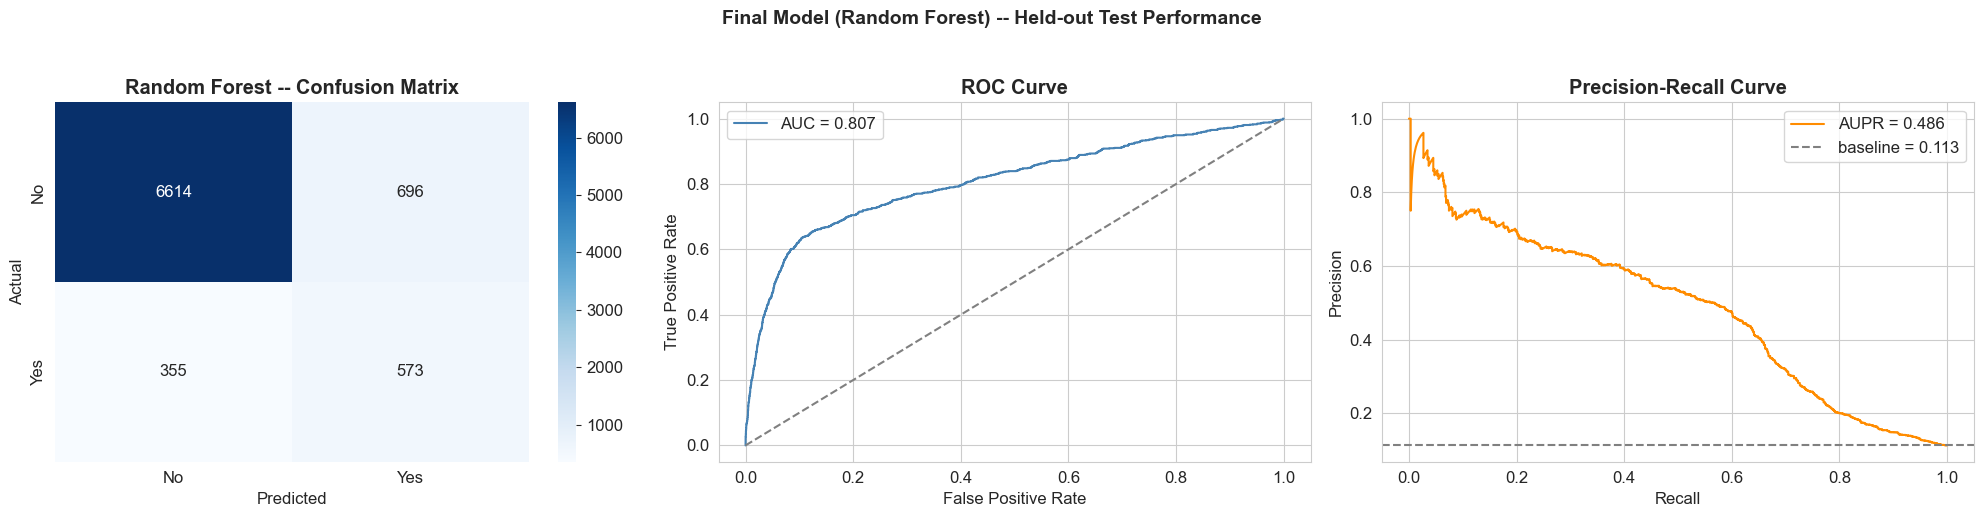

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title(f'{best_name} -- Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc_score(y_test, proba):.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, proba)
axes[2].plot(rec, prec, color='darkorange', label=f'AUPR = {average_precision_score(y_test, proba):.3f}')
axes[2].axhline(y=y_test.mean(), linestyle='--', color='gray', label=f'baseline = {y_test.mean():.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold'); axes[2].legend()

plt.suptitle(f'Final Model ({best_name}) -- Held-out Test Performance', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Confusion matrix: of 928 real subscribers the model catches ~62% (recall) while flagging some
# non-subscribers still as false positives (precision ~45%), the expected behaviour under imbalance.
# ROC curve sits well above the diagonal (AUC 0.81) and the PR curve well above the 0.113 baseline
# (AUPR 0.49, ~4x chance).

---
## 6. Summary & Discussion

### Key Findings — Phase V

**Validation method:**
- Nested 5×3 cross-validation on the FULL 33k training set (feasible in a few minutes — the RBF
  SVM is the only slow part, ~4 min), scored on Accuracy, F1, ROC-AUC and AUPR, all models on
  identical folds (paired). The chosen model was then retrained on the full train and confirmed on
  the held-out test set.
- Regression metrics (R², MAE, RMSE) are **not applicable** — our task is binary classification.

**Model comparison & selection:**
- On full data the families **clearly separated**: the two **ensembles lead** — Hist Gradient Boosting
  (ROC-AUC 0.798, AUPR 0.466) and Random Forest (0.792, 0.466), above Logistic Regression
  (0.785 / 0.415) and the RBF SVM (0.775 / 0.398), the baseline is at chance.
- **Correct (Nadeau–Bengio) paired t-tests** (which account for the dependence between CV folds):
  we tried a  naive test that flagged HistGB > RF on ROC-AUC (p = 0.015), but after correction that gap is
  **no longer significant** (p = 0.054), on AUPR they are a clear tie (p = 0.92). So the two
  ensembles are **statistically indistinguishable on both ranking metrics**, and both clearly beat
  Logistic and SVM. Random Forest has the best F1 (0.494) and accuracy (0.865).
- With the ensembles tied on AUPR, we break the tie by F1 → **Random Forest is the final model**
  (also faster and the model profiled in Phase IV). **Hist Gradient Boosting is its statistical
  equal** — an equally valid choice if ROC-AUC were the priority.
- **Final model: Random Forest** (`class_weight='balanced'`, `n_estimators=300`, `min_samples_leaf=5`).
  Held-out test: **ROC-AUC 0.807, AUPR 0.486, F1 0.52, accuracy 0.87** — beating logistic, SVM and the
  baseline, and matching the Phase IV result.

**Why Random Forest (the practical choice):** tied-or-better on every metric that matters under
imbalance, fast to train, a free OOB validation check.

### Project-wide takeaways (Phases I–V)

- **EDA & preprocessing:** 41,188 rows, 11.3% positive, dropped the redundant `pdays`, excluded the
  leaky `duration`, encoded sensibly (ordinal / binary / one-hot) and standardized.
- **Feature extraction/selection:** PCA showed a genuinely high-dimensional, 3-domain structure.
  L1/Lasso and a Phase III interaction experiment confirmed most features carry non-redundant signal.
- **What drives subscription:** the **macroeconomic block** (euribor3m, emp.var.rate, nr.employed) is
  the dominant driver (grouped-permutation ROC-AUC drop ≈ 0.19), followed by **campaign history**
  (contact, poutcome, campaign). Client demographics barely matter, a strong economy / high rates
  pushes *against* subscription.
- **Dataset challenges:** class imbalance (handled via class weights + AUPR/F1); the leaky `duration`
  (excluded — it is the single biggest predictor, so its removal sets the realistic ceiling),
  multicollinearity in the macro block (|r|>0.9), and SVM
  scalability (O(n²–n³) — it dominates even the full-data nested CV at ~4 min, while trees finish in
  seconds and scale effortlessly).
- **Performance ceiling:** every family flatens around **ROC-AUC 0.81 / AUPR 0.49**, this is because
  of the observed class overlap (without `duration`), not by model choice. Ensembles raise it slightly above
  the linear/kernel plateau.

